<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_9_2_4_AudiBERT_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AudiBERT model adapted by Toto et al. (2021)
Toto, E., Tlachac, M., & Rundensteiner, E. A. (2021). AudiBERT: A Deep Transfer Learning Multimodal Classification Framework for Depression Screening. Proceedings of the 30th ACM International Conference on Information & Knowledge Management, 4145–4154. https://doi.org/10.1145/3459637.3481895.

Original Google Colab by Toto et al. (2021): https://colab.research.google.com/drive/1g_smMt_-qQZyq5EaXBEo8XBu2KrvhDLI?usp=sharing

Webpage by Toto et al. (2021): https://emutivo.wpi.edu/index.php/publications/


Large files are provided here (https://osf.io/4kg3p/overview?view_only=5bc373abcd294764ad9b5e3426538d23)

*   AudiBERTDist_withdataset_preloadBERT.tar.gz
*   AudiBERTDist_withdataset_preloadBERT_AFFECTIVE.tar.gz
*   socialcognitive_model_epoch_1.model
*   affective_model_epoch_3.model



# **Training the AudiBERT model**

In [ ]:
%reset -f
!apt-get update
!apt-get install sqlite3 libblas-dev liblapack-dev
!pip install numpy pandas scikit-learn transformers "tensorflow>2.0.0" torch torchaudio argparse six resampy SoundFile torchtext==0.6.0 jupyter papermill pydub

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,312 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,676 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [3,612 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,911 kB]
Hit:13 https://ppa.launchpadconte

In [ ]:
!sqlite3 --version
%env LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
%env BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
%matplotlib inline
!ls /usr/local/cuda/lib64/ | grep "libcudart\.so\.11\.0"
import os
os.environ['LD_LIBRARY_PATH']+=":/usr/local/cuda/lib64/"
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
!echo $LD_LIBRARY_PATH
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1
env: LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
env: BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
/usr/lib64-nvidia:/usr/local/cuda/lib64/


If training model for social-cognitive classifications, run
```
!tar -xzf '.../AudiBERTDist_withdataset_preloadBERT.tar.gz' --strip-components 1
```

If training model for affective classifications, run
```
!tar -xzf '.../AudiBERTDist_withdataset_preloadBERT_AFFECTIVE.tar.gz' --strip-components 1
```

In [ ]:
!cd expResults && ./createDb.sh diskexperiments.db && cd ..

In [ ]:
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier.py --epochs 20 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

Streaming output truncated to the last 5000 lines.
===========B. CHECK FOR NAN in AUDIO TENSORS================
Pooled Attention
tensor([[ 0.0479,  0.0981, -0.0082,  ..., -0.0241, -0.0689,  0.0180]],
       device='cuda:0')
Gender not included in attention layer
**********************SENTENCE 110 of 729******************************
/content/drive/MyDrive/EDM25/M4/audio/25.wav
Start time (sec): tensor([1266.9630], device='cuda:0')
End time (sec): tensor([1267.5990], device='cuda:0')
===========A. CHECK FOR NAN in BERT TENSORS================
/content/drive/MyDrive/EDM25/M4/audio/temp_bertload2.wav used and removed
===========B. CHECK FOR NAN in AUDIO TENSORS================
Pooled Attention
tensor([[-0.0049,  0.0812, -0.0002,  ..., -0.0121, -0.0161, -0.0015]],
       device='cuda:0')
Gender not included in attention layer
**********************SENTENCE 111 of 729******************************
/content/drive/MyDrive/EDM25/M4/audio/0.wav
Start time (sec): tensor([1227.9041], device='cuda

# **Testing the AudiBERT model**

## Using Epoch 1 to obtain Social-Cognitive classifications

In [ ]:
%reset -f
!apt-get update
!apt-get install sqlite3 libblas-dev liblapack-dev
!pip install numpy pandas scikit-learn transformers "tensorflow>2.0.0" torch torchaudio argparse six resampy SoundFile torchtext==0.6.0 jupyter papermill pydub

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,080 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,354 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Pa

In [ ]:
!sqlite3 --version
%env LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
%env BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
%matplotlib inline
# !which nvcc
!ls /usr/local/cuda/lib64/ | grep "libcudart\.so\.11\.0"
import os
os.environ['LD_LIBRARY_PATH']+=":/usr/local/cuda/lib64/"
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
!echo $LD_LIBRARY_PATH
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1
env: LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
env: BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
/usr/lib64-nvidia:/usr/local/cuda/lib64/


In [ ]:
!tar -xzf '.../AudiBERTDist_withdataset_preloadBERT.tar.gz' --strip-components 1

In [ ]:
!cd expResults && ./createDb.sh diskexperiments.db && cd ..

In [ ]:
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier_testing.py --epochs 1 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

BERT_WAV2VEC_DUALSELFATTN
1281BERT_WAV2VEC_DUALSELFATTNTrueFalse1doing_todayBERT_WAV2VEC_DUALSELFATTNaggregatedQuestionSplits_padded/1515TrueFalse
0
There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Number of training sentences: 4,866

Number of unique labels in train data: 13; ([ 0  1  2  3  4  5  6  7  8  9 10 11 12])
Loading BERT tokenizer...
2025-10-14 21:25:06.132380: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760477106.152835   13581 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760477106.158911   13581 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760477106.174626   13581 computation_placer.cc:177] computation pl

## Using Epoch 3 to obtain Social-Cognitive classifications

In [ ]:
%reset -f
!apt-get update
!apt-get install sqlite3 libblas-dev liblapack-dev
!pip install numpy pandas scikit-learn transformers "tensorflow>2.0.0" torch torchaudio argparse six resampy SoundFile torchtext==0.6.0 jupyter papermill pydub

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,667 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,911 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,230 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/ma

In [ ]:
!sqlite3 --version
%env LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
%env BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
%matplotlib inline
!ls /usr/local/cuda/lib64/ | grep "libcudart\.so\.11\.0"
import os
os.environ['LD_LIBRARY_PATH']+=":/usr/local/cuda/lib64/"
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
!echo $LD_LIBRARY_PATH
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1
env: LAPACK=/usr/lib/x86_64-linux-gnu/lapack/liblapack.a
env: BLAS=/usr/lib/x86_64-linux-gnu/blas/libblas.a
/usr/lib64-nvidia:/usr/local/cuda/lib64/


In [ ]:
!tar -xzf '/content/drive/MyDrive/EDM25/M4/AudiBERTDist_withdataset_preloadBERT_AFFECTIVE.tar.gz' --strip-components 1

In [ ]:
!cd expResults && ./createDb.sh diskexperiments.db && cd ..

In [ ]:
!python -m cProfile -o bertbasedmulticlassifier.profile bertbasedmulticlassifier_testing.py --epochs 3 --question doing_today --modelName BERT_WAV2VEC_DUALSELFATTN --useAudio True --useGender False --logtodb True --maxruns 20 --useLSTM True

BERT_WAV2VEC_DUALSELFATTN
1281BERT_WAV2VEC_DUALSELFATTNTrueFalse3doing_todayBERT_WAV2VEC_DUALSELFATTNaggregatedQuestionSplits_padded/1515TrueFalse
0
There are 1 GPU(s) available.
We will use the GPU: Tesla T4
Number of training sentences: 1,222

Number of unique labels in train data: 3; ([0 1 2])
Loading BERT tokenizer...
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 172kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 51.4MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 67.2MB/s]
config.json: 100% 570/570 [00:00<00:00, 2.13MB/s]
2025-02-12 14:45:08.306914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739371508.329565    6665 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739371508.336313    6665 cuda_blas.cc:1418] Unable to register

# **AudiBERT classification report and normalised confusion matrix**

## Social-cognitive Classifications

Figure 5.1: Row-normalised confusion matrix with values in each cell showing the proportion of instances from the true class that were predicted as a particular class in the social-cognitive dimension for the implemented models.

Classification Report:
               precision    recall  f1-score   support

         SS1      0.263     0.233     0.247        43
         SS2      0.584     0.669     0.624       245
         SS3      0.316     0.343     0.329        70
         SS4      1.000     0.167     0.286         6
         SS5      0.533     0.421     0.471        19
         SS6      0.167     0.080     0.108        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.689     0.752     0.719       318
         SC2      0.693     0.564     0.622       172

   micro avg      0.598     0.598     0.598       912
   macro avg      0.424     0.323     0.340       912
weighted avg      0.587     0.598     0.587       912
 samples avg      0.598     0.598     0.598       912

Accuracy: 0.598
Precision: 0.587
Recall: 0.598
F1 Score: 0.587



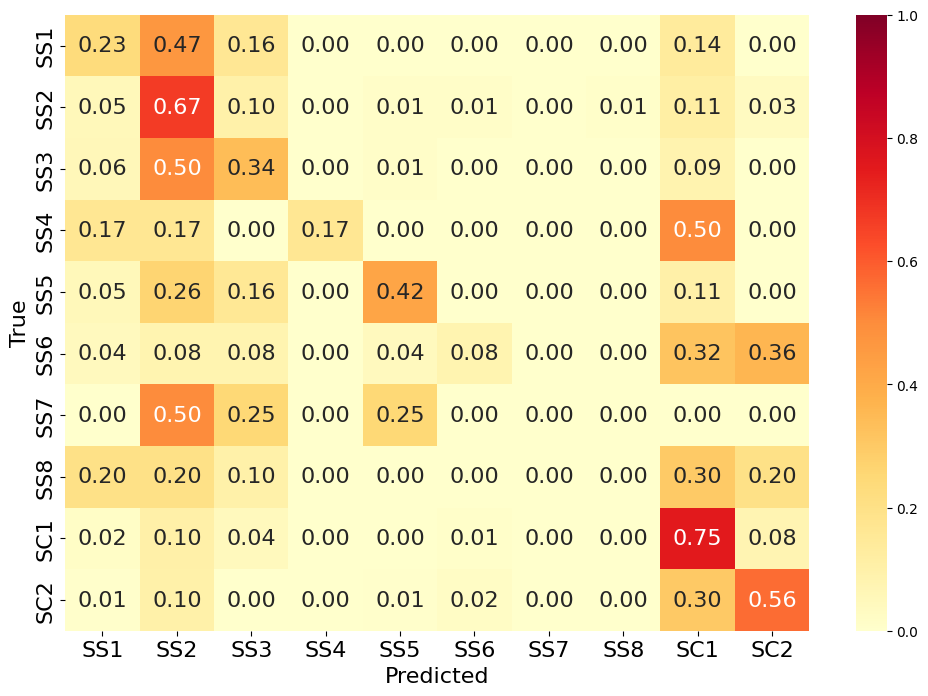

In [ ]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the data
data = pd.read_pickle('.../socialcognitive_testing_result_1.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==1]

# Label dictionary
label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.show()

## Affective Classifications

Figure 5.2: Row-normalised confusion matrix with values in each cell showing the proportion of instances from the true class that were predicted as a particular class in the affective dimension for the implemented models.

Classification Report:
               precision    recall  f1-score   support

         AS1      0.849     0.886     0.867       114
         AS2      0.922     0.897     0.909       184
         AS3      0.750     0.750     0.750         8

   micro avg      0.889     0.889     0.889       306
   macro avg      0.840     0.844     0.842       306
weighted avg      0.890     0.889     0.889       306
 samples avg      0.889     0.889     0.889       306

Accuracy: 0.889
Precision: 0.890
Recall: 0.889
F1 Score: 0.889



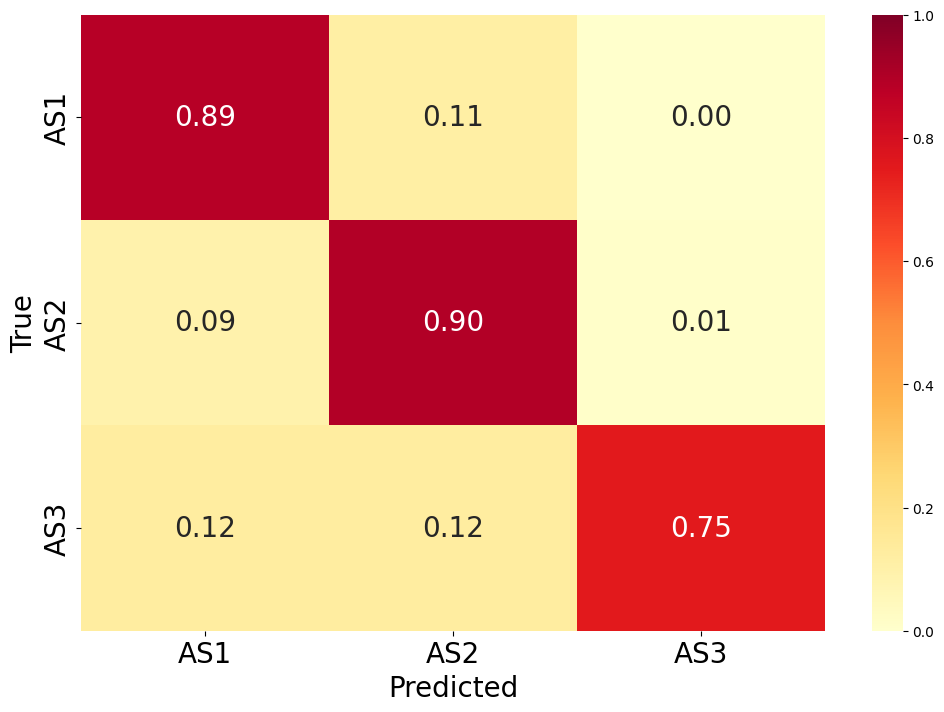

In [ ]:
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the data
data = pd.read_pickle('.../affective_testing_result_3.pkl')
df = pd.DataFrame(data)
df = df[df["epoch"]==3]

# Label dictionary
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

# Extract true labels and predictions
true_vals = np.hstack(df['true_labels'].values)
predictions = np.hstack(df['predictions'].values)

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.show()